# Linear Analysis

Parse `edp_metrics.txt`, build the wide dataframes used by the plots, and visualize DRAM utilization vs normalized performance.

In [5]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

METRICS_PATH = Path('/home/ac.zzheng/power/GPGPU/data/H100/edp_metrics.txt')
FIG_DIR = Path('/home/ac.zzheng/power/GPGPU/data/fig')
SECTION_RE = re.compile(r'^===== .*?/([^/ ]+) =====$')


def parse_edp_metrics(metrics_path: Path) -> pd.DataFrame:
    rows = []
    current_benchmark = None

    for raw_line in metrics_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue

        match = SECTION_RE.match(line)
        if match:
            current_benchmark = match.group(1)
            continue

        if current_benchmark is None or line.startswith('cap=') or line.startswith('gpu_count'):
            continue

        parts = line.split()
        if len(parts) < 9:
            continue

        rows.append({
            'benchmark': current_benchmark,
            'gpu_count': int(parts[0]),
            'performance': float(parts[1]),  # Runtime for this H100 dataset.
            'avg_power': float(parts[2]),
            'dram_sum': float(parts[3]),
            'sm_sum': float(parts[4]),
            'fp_sum': float(parts[5]),
            'dram_min_scaled': float(parts[6]),
            'sm_min_scaled': float(parts[7]),
            'fp_min_scaled': float(parts[8]),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        raise ValueError(f'No rows parsed from {metrics_path}')

    df['gpu_label'] = df['gpu_count'].astype(str) + ' GPU'
    return df


edp_df = parse_edp_metrics(METRICS_PATH)
perf_results = edp_df['benchmark'].unique().tolist()
col_names = [f'{gpu_count} GPU' for gpu_count in sorted(edp_df['gpu_count'].unique())]
gpu_cols_int = [int(col.split()[0]) for col in col_names]

perf_from_edp_df = (
    edp_df.pivot(index='benchmark', columns='gpu_label', values='performance')
    .reindex(columns=col_names)
    .sort_index()
)

dram_sum_df = (
    edp_df.pivot(index='benchmark', columns='gpu_label', values='dram_sum')
    .reindex(columns=col_names)
    .sort_index()
)

dram_min_scaled_df = (
    edp_df.pivot(index='benchmark', columns='gpu_label', values='dram_min_scaled')
    .reindex(columns=col_names)
    .sort_index()
)

# Default DRAM metric for the plots below. Swap to dram_min_scaled_df if needed.
dram_df = dram_sum_df

perf_from_edp_df


gpu_label,1 GPU,2 GPU,3 GPU,4 GPU
benchmark,,,,
bert,37.94,26.42,24.34,21.03
cloverleaf,36.99,22.66,19.37,16.83
gpt2,19.15,15.18,15.13,15.05
hpgmg,10.09,11.95,42.93,395.65
lbm,55.41,29.83,21.98,18.82
minisweep,140.82,77.25,57.47,43.61
miniweather,57.01,82.00,84.09,83.89
pot3d,133.09,109.34,104.33,102.72
resnet50,38.88,25.45,20.81,20.65


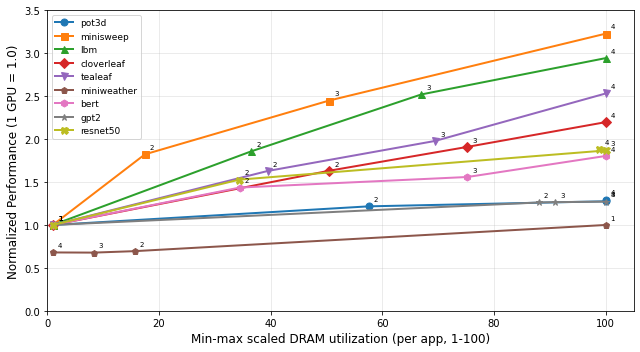

In [6]:
# Performance is runtime, so normalized perf = runtime_1GPU / runtime_NGPU
norm_perf = perf_from_edp_df.rdiv(perf_from_edp_df['1 GPU'], axis=0).round(3)


def minmax_scale_rows(df, out_min=1, out_max=100):
    row_min = df.min(axis=1)
    row_max = df.max(axis=1)
    row_range = row_max - row_min

    scaled = df.sub(row_min, axis=0).div(row_range.replace(0, np.nan), axis=0)
    scaled = scaled * (out_max - out_min) + out_min
    scaled = scaled.where(row_range.ne(0), out_min)
    return scaled.round(3)


# Min-max scale only DRAM, per app, to [1, 100]
norm_dram = minmax_scale_rows(dram_df, 1, 100)

target_benchmarks = [
    'pot3d', 'minisweep', 'lbm', 'cloverleaf', 'tealeaf', 'miniweather',
    'bert', 'gpt2', 'resnet50',
]
target_benchmarks = [bench for bench in target_benchmarks if bench in norm_perf.index]
norm_perf = norm_perf.reindex(target_benchmarks)
norm_dram = norm_dram.reindex(target_benchmarks)

if norm_perf.empty:
    raise ValueError(f'No target benchmarks found. Parsed benchmarks: {sorted(perf_results)}')

FIG_DIR.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']

for i, app in enumerate(norm_perf.index):
    x_vals = norm_dram.loc[app].values
    y_vals = norm_perf.loc[app].values
    ax.plot(x_vals, y_vals, marker=markers[i % len(markers)], label=app, linewidth=2, markersize=7)
    for j, col in enumerate(col_names):
        gpu_n = col.split()[0]
        ax.annotate(f'{gpu_n}', (x_vals[j], y_vals[j]), textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('Min-max scaled DRAM utilization (per app, 1-100)', fontsize=12)
ax.set_ylabel('Normalized Performance (1 GPU = 1.0)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 105)
ax.set_ylim(0, 3.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / 'dram_utilization_vs_performance.png', dpi=300)
plt.show()


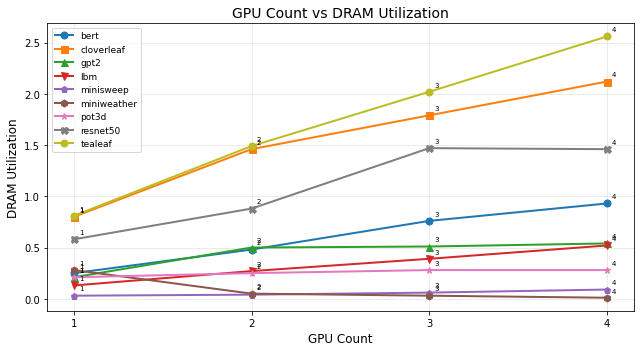

In [7]:
col_names = [f'{gpu_count} GPU' for gpu_count in sorted(edp_df['gpu_count'].unique())]
gpu_cols_int = [int(col.split()[0]) for col in col_names]

# Plot: GPU count vs DRAM utilization for each app
fig, ax = plt.subplots(figsize=(9, 5))
markers = ['o', 's', '^', 'D', 'v', 'p', 'h', '*', 'X']

gpu_vals = gpu_cols_int

for i, app in enumerate(dram_df.index):
    if app not in target_benchmarks:
        continue

    y_vals = dram_df.loc[app, col_names].values
    ax.plot(gpu_vals, y_vals, marker=markers[i % len(markers)], label=app,
            linewidth=2, markersize=7)

    for j, gpu_n in enumerate(gpu_vals):
        ax.annotate(f'{gpu_n}', (gpu_vals[j], y_vals[j]),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

ax.set_xlabel('GPU Count', fontsize=12)
ax.set_ylabel('DRAM Utilization', fontsize=12)
ax.set_title('GPU Count vs DRAM Utilization', fontsize=14)
ax.set_xticks(gpu_vals)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./fig/gpu_count_vs_dram_utilization.png', dpi=300)
plt.show()